# Amazon Ticker Reproducibility
Ethan

## Environment

**Python**: Version 3.12.9

<a href='https://www.python.org/downloads/release/python-3129'>https://www.python.org/downloads/release/python-3129/</a>

Install requirements.txt inside a powershell terminal:
1. cd code
2. py -3.12 -m venv ..\environment\ethan-venv
3. ..\environment\ethan-venv\Scripts\Activate.ps1
4. python -m pip install --upgrade pip setuptools wheel
5. pip install -r ..\environment\requirements.txt
6. python -m ipykernel install --user --name ethan-venv --display-name "ethan-venv"
7. Select the Jupyter kernel

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import random
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

%matplotlib inline
pd.set_option('display.max_columns', 500)
plt.style.use('fivethirtyeight')

## Setup

For Amazon, the paper reports these results:
- MAE: 6.78
- MSE: 65.43
- RMSE: 8.09
- MAPE: 3.05%

In [2]:
paper_results = {'MAE': 6.78, 'MSE': 65.43, 'RMSE': 8.09, 'MAPE': 3.05}

Paper didn't use a seed but I'll use 42 because that's the universal pick

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

## Data

Paper code appendix shows loading AAPL from April 1, 2024 to April 1, 2025. However, later on in the notebook, some of the recreation graphs were missing data. I found the 24th to be the sweet spot.

In [4]:
amzn = yf.download("AMZN", start = '2024-04-01', end = '2025-04-24')
amzn.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2024-04-01,180.970001,183.000000,179.949997,180.789993,29174500
2024-04-02,180.690002,180.789993,178.380005,179.070007,32611500
2024-04-03,182.410004,182.869995,179.800003,179.899994,31046600
2024-04-04,180.000000,185.100006,180.000000,184.000000,41624300
2024-04-05,185.070007,186.270004,181.970001,182.380005,42374000


Originally used a yfinance version from feb 2025. That caused a bunch of errors like too many requests yatata. Latest version of the package fixed the issue.

Also, building the venv with tensorflow, on proton drive broke my pip. So spent a good 3 hours dealing with why the data issue and pip issue, yay!

Saving data incase things go down hill again when I restart my notebook

In [5]:
amzn.columns = [col[0] for col in amzn.columns]
amzn.to_csv("../data/amzn.csv")
amzn.head()

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,180.970001,183.000000,179.949997,180.789993,29174500
2024-04-02,180.690002,180.789993,178.380005,179.070007,32611500
2024-04-03,182.410004,182.869995,179.800003,179.899994,31046600
2024-04-04,180.000000,185.100006,180.000000,184.000000,41624300
2024-04-05,185.070007,186.270004,181.970001,182.380005,42374000


Load it back in

In [6]:
df_amazon = pd.read_csv("../data/amzn.csv", parse_dates=["Date"])
df_amazon = df_amazon.set_index("Date")

## EDA

In [7]:
display(df_amazon.head())
df_amazon.info()
print(f"----\nShape {df_amazon.shape}\n----")
display(df_amazon.describe())

,Close,High,Low,Open,Volume
Date,,,,,
2024-04-01,180.970001,183.000000,179.949997,180.789993,29174500
2024-04-02,180.690002,180.789993,178.380005,179.070007,32611500
2024-04-03,182.410004,182.869995,179.800003,179.899994,31046600
2024-04-04,180.000000,185.100006,180.000000,184.000000,41624300
2024-04-05,185.070007,186.270004,181.970001,182.380005,42374000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 267 entries, 2024-04-01 to 2025-04-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   267 non-null    float64
 1   High    267 non-null    float64
 2   Low     267 non-null    float64
 3   Open    267 non-null    float64
 4   Volume  267 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 12.5 KB
----
Shape (267, 5)
----


,Close,High,Low,Open,Volume
count,267.000000,267.000000,267.000000,267.000000,2.670000e+02
mean,195.635131,197.925169,193.129925,195.682247,4.168678e+07
std,19.079477,19.005443,19.057794,19.080850,1.805761e+07
min,161.020004,162.960007,151.610001,154.210007,1.500750e+07
25%,182.279999,184.879997,180.150002,182.795006,3.058165e+07
50%,188.759995,190.600006,186.300003,188.350006,3.741770e+07
75%,207.875000,209.594994,204.375000,207.209999,4.467135e+07
max,242.059998,242.520004,238.029999,239.020004,1.414484e+08


In [8]:
print(df_amazon.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Reproduce

### Closing Price

Recreating closing price graph (how I found out april 1, 2025 was not the right cut off)

Text(0, 0.5, 'Close')

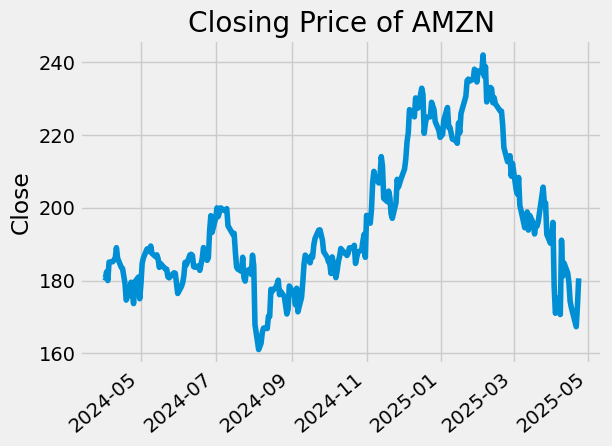

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(df_amazon.index, df_amazon["Close"])
plt.title("Closing Price of AMZN")
plt.xticks(rotation=40, ha='right')
plt.ylabel("Close")

### Day Moving Averages

The paper says it uses 10 day, 20 day, and 50 day moving averages. It says it helps derive features that assist the LSTM model in understanding trends to improve prediction accuracy.

graph recreation of the moving averages

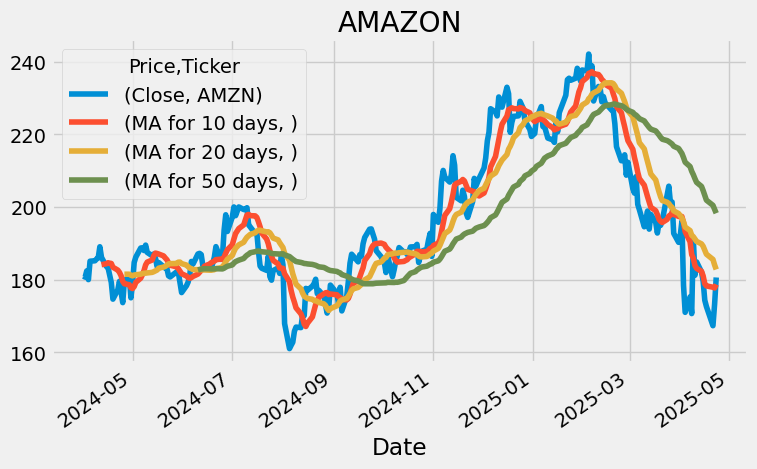

In [10]:
df_amazon["MA10"] = df_amazon["Close"].rolling(window=10).mean()
df_amazon["MA20"] = df_amazon["Close"].rolling(window=20).mean()
df_amazon["MA50"] = df_amazon["Close"].rolling(window=50).mean()
plt.figure(figsize=(8, 4))
plt.plot(df_amazon.index, df_amazon["Close"], label="(Close, AMZN)")
plt.plot(df_amazon.index, df_amazon["MA10"], label="(MA for 10 days, )")
plt.plot(df_amazon.index, df_amazon["MA20"], label="(MA for 20 days, )")
plt.plot(df_amazon.index, df_amazon["MA50"], label="(MA for 50 days, )")
plt.title("AMAZON")
plt.xlabel("Date")
plt.xticks(rotation=35, ha='right')
plt.legend(title="Price,Ticker")

### Daily Returns

It says daily returns show percent change in price from one trading day to the next.

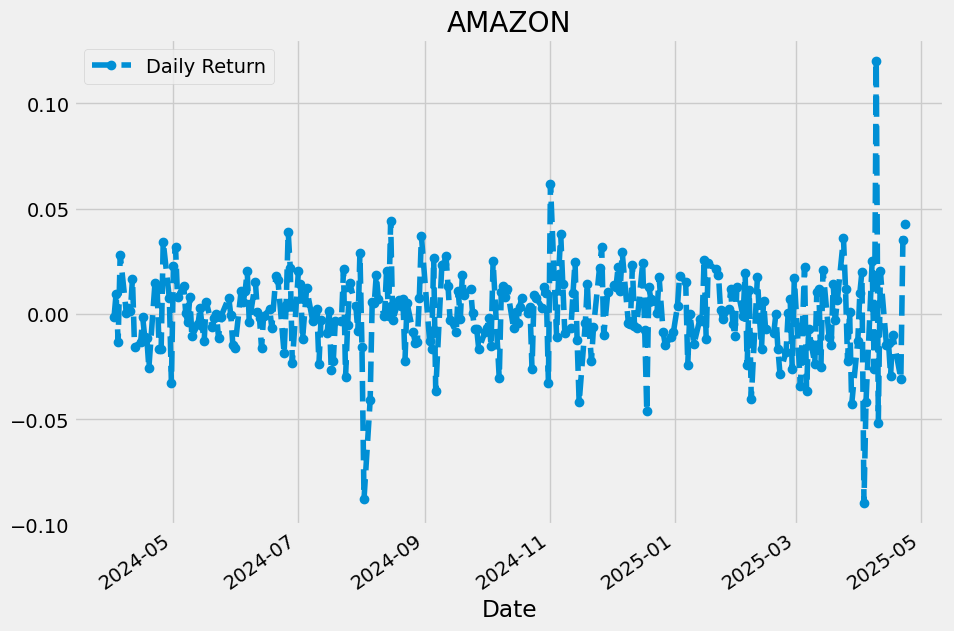

In [11]:
df_amazon["Daily Return"] = df_amazon["Close"].pct_change()
plt.figure(figsize=(10, 6))
plt.plot(df_amazon.index, df_amazon["Daily Return"], label="Daily Return", linestyle="--", marker="o")
plt.title("AMAZON")
plt.xlabel("Date")
plt.xticks(rotation=35, ha='right')
plt.legend()

### Daily Return Distribution

Text(0, 0.5, 'Counts')

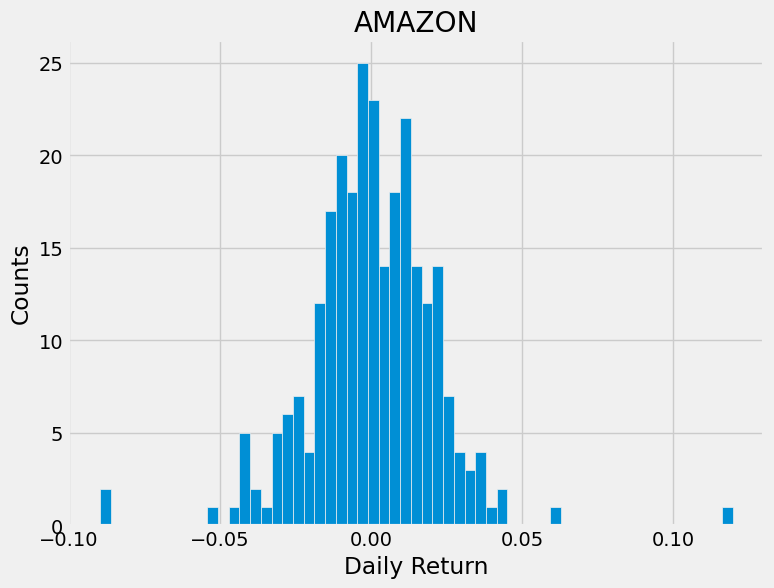

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(df_amazon["Daily Return"], bins=59, alpha=1)
plt.title("AMAZON")
plt.xlabel("Daily Return")
plt.ylabel("Counts")

Can't seem to guess the bin right but this is as close as I can get

## Simple Risk and Return Summary

In [13]:
print(f"Average daily return is {df_amazon["Daily Return"].mean()}")
print(f"Risk is {df_amazon["Daily Return"].std()}")

Average daily return is 0.00020956235167894893
Risk is 0.02088346816650881


The paper doesn't list the exact Amazon mean return and risk numbers. It does say Amazon is one of the stocks with the higher standard deviation and more uncertainty. My numbers seem to fit that pattern because of the small average daily mean and a noticeable std.

### Close Data
This is the target data seen in the paper's code appendex

In [14]:
close_data = df_amazon[["Close"]].copy()
display(close_data.head())
print(close_data.shape)
closing_prices = close_data.values.reshape(-1, 1)

,Close
Date,
2024-04-01,180.970001
2024-04-02,180.690002
2024-04-03,182.410004
2024-04-04,180.000000
2024-04-05,185.070007


(267, 1)


### Sentiment Analyzer
Code appendix just has a placeholder new title and we don't really know what they actually used to test. So this is where things are not going to reproduce correctly

In [16]:
analyzer = SentimentIntensityAnalyzer()
news_data = ["Sample news article text"]
sentiments = [analyzer.polarity_scores(text)["compound"] for text in news_data]
sentiments = np.array(sentiments).reshape(-1, 1)
sentiments = np.repeat(sentiments, len(closing_prices)).reshape(-1, 1) # make sure we have the same shape as closing_prices
print(f"Closing prices shape is {closing_prices.shape}")
print(f"Sentiments shape is {sentiments.shape}")
print(f"Sentiment score used for all days is {sentiments[0][0]}")

Closing prices shape is (267, 1)
Sentiments shape is (267, 1)
Sentiment score used for all days is 0.0


### Normalize Prices and Sentiments

In [17]:
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(closing_prices)
scaled_sentiments = scaler.fit_transform(sentiments)

scaled_df = pd.DataFrame(
    {
        "Scaled Price": scaled_prices.flatten(),
        "Scaled Sentiment": scaled_sentiments.flatten()
    }, 
    index = close_data.index
)

display(scaled_df.head())
print(scaled_df.shape)

,Scaled Price,Scaled Sentiment
Date,,
2024-04-01,0.246175,0.0
2024-04-02,0.242720,0.0
2024-04-03,0.263944,0.0
2024-04-04,0.234205,0.0
2024-04-05,0.296767,0.0


(267, 2)


### Build 60 Day Sequences
this is exactly what the code appendix had

In [18]:
window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_prices)):
    X.append(np.column_stack((
        scaled_prices[i-window_size:i, 0],
        scaled_sentiments[i-window_size:i, 0]
    )))
    y.append(scaled_prices[i, 0])
X, y = np.array(X), np.array(y)

print(f"X shape is {X.shape}")
print(f"y shape is {y.shape}")
print(f"One sample shape is {X[0].shape}")

X shape is (207, 60, 2)
y shape is (207,)
One sample shape is (60, 2)


### Train Test Split
Code appendix says 80-20 ratio

In [19]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_train shape {y_train.shape}")
print(f"y_test shape {y_test.shape}")

X_train shape (165, 60, 2)
X_test shape (42, 60, 2)
y_train shape (165,)
y_test shape (42,)


### LSTM Model
Exact model from the code appendix

In [20]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 2)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

model.summary()

c:\Users\edann\Desktop\DATA6550-Reproducibility\environment\ethan-venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [21]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1684
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0244
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0213
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0166
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0128
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0138
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0116
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0111
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0107
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0109
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0101
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0095
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0099
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0099
Epoch 16/100
6/6 ━━

### Make Predictions

In [22]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions shape is {predictions.shape}")
print(f"Actual values shape is {y_test_actual.shape}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Predictions shape is (42, 1)
Actual values shape is (42, 1)


### Evaluate Model

In [23]:
mae = np.mean(np.abs(predictions - y_test_actual))
mse = np.mean((predictions - y_test_actual) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MAE: 0.0934
MSE: 0.0122
RMSE: 0.1103
MAPE: 38.1549%


## Comparison

In [24]:
comparison_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE"],
    "Paper Amazon": [6.78, 65.43, 8.09, 3.05],
    "My Amazon": [mae, mse, rmse, mape]
})
comparison_df["Difference"] = comparison_df["My Amazon"] - comparison_df["Paper Amazon"]

display(comparison_df)

,Metric,Paper Amazon,My Amazon,Difference
0,MAE,6.78,0.093429,-6.686571
1,MSE,65.43,0.012161,-65.417839
2,RMSE,8.09,0.110276,-7.979724
3,MAPE,3.05,38.154850,35.104850


Clearly not having the sentiment news data makes the paper results unreproducible